In [1]:
# import packages
import pandas as pd
from pathlib import Path

# use path import to simplify the finding of the file needed for EDA
file_path = Path('../data/raw/data.csv')

# try-catch block to verify filepath
try:
    df = pd.read_csv(file_path, sep=';')
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found")
    exit()

# Print dataframe shape
print(f"DataFrame shape: {df.shape}")

# Print the columns and rows of the dataframe
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")

# Print the first 5 rows of information
print(df.head())

DataFrame shape: (4424, 37)
Columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflatio

In [2]:
# Check target distribution
print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True).mul(100).round(1))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64


In [7]:
# Fix column name with the tab character
df.columns = df.columns.str.strip()
print(df.columns.tolist()) # confirm that it is gone

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [5]:
# Check for missing values
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [6]:
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})
print(df['Target'].value_counts())

Target
0    3003
1    1421
Name: count, dtype: int64


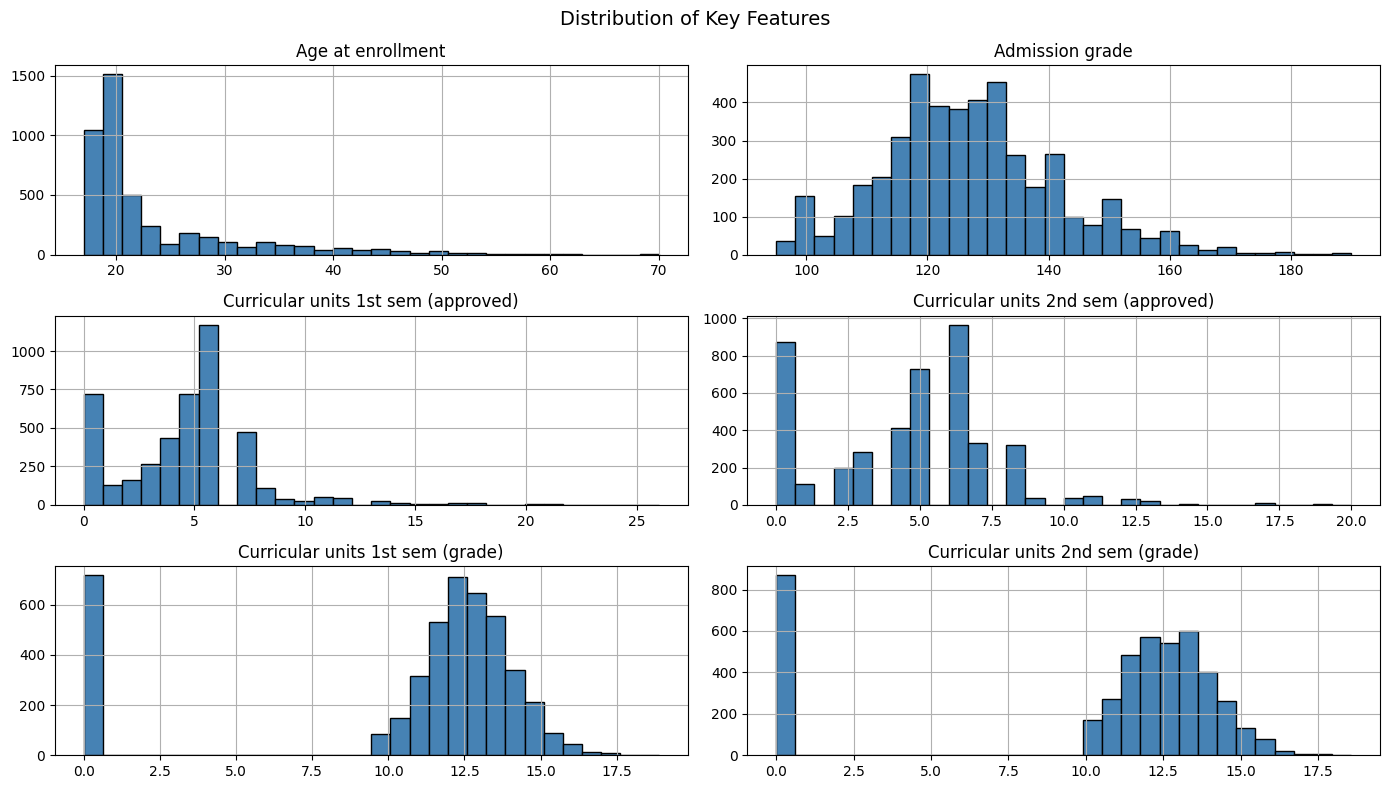

In [10]:
import matplotlib.pyplot as plt

numeric_cols = ['Age at enrollment', 'Admission grade', 
                'Curricular units 1st sem (approved)',
                'Curricular units 2nd sem (approved)',
                'Curricular units 1st sem (grade)',
                'Curricular units 2nd sem (grade)']

df[numeric_cols].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Key Features', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
correlation = df.corr()['Target'].sort_values(ascending=False)
print(correlation)

Target                                            1.000000
Age at enrollment                                 0.254215
Debtor                                            0.229407
Gender                                            0.203983
Application mode                                  0.198458
Marital status                                    0.093712
Curricular units 2nd sem (without evaluations)    0.079901
Mother's qualification                            0.064958
Curricular units 1st sem (without evaluations)    0.054230
Previous qualification                            0.049379
Inflation rate                                    0.027826
Father's qualification                            0.018295
Unemployment rate                                 0.012980
Nacionality                                       0.008346
Educational special needs                         0.002806
International                                    -0.010360
Mother's occupation                              -0.0219